# Hedera Staking Simulation Visualization

This notebook demonstrates various visualizations of the Hedera staking simulation results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Dict, List, Tuple
import pandas as pd

from staking.accounts import FeeCollection, Treasury, StakingRewardsPool, NodeRewardsPool
from staking.stakingenv import StakingEnvironment

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [2]:
@dataclass
class Snapshot:
    day: int
    fees: float
    rs: float
    rn: float
    treasury_balance: float
    staking_pool_balance: float
    node_pool_balance: float | None
    total_staker_balance: float
    total_node_balance: float
    active_nodes: int
    staker_rewards: Dict[int, float]
    node_rewards: Dict[int, float]


def sum_balances(balance_map: Dict[int, float]) -> float:
    return float(sum(balance_map.values()))


def run_simulation(
    num_stakers: int = 500,
    num_nodes: int = 32,
    days: int = 30,
    seed: int = 123,
) -> Tuple[List[Snapshot], StakingEnvironment]:
    """Run the simulation and collect daily snapshots from the current environment."""
    rng = np.random.default_rng(seed)

    treasury = Treasury(initial_balance=3284822.0)
    staking_pool = StakingRewardsPool(initial_balance=215204097.0)
    node_pool = NodeRewardsPool(initial_balance=993358.0)
    fee_collection = FeeCollection(
        share_staking_pool=0.10,
        share_node_pool=0.10,
    )

    reward_params = dict(
        param_reward_a=0.01,
        param_reward_b=0.01,
        param_reward_c=5.0,
        param_reward_m=10.0,
    )

    env = StakingEnvironment(
        num_stakers=num_stakers,
        num_nodes=num_nodes,
        num_hbars=42000000000,
        staker_pareto_shape=2.0,
        node_pareto_shape=2.0,
        treasury=treasury,
        staking_pool=staking_pool,
        node_pool=node_pool,
        fee_collection=fee_collection,
        reward_params=reward_params,
        node_fee_per_tx=1e-5,
        staker_activity_min=0.1,
        staker_activity_scale=1.0,
        rng=rng,
    )

    history: List[Snapshot] = []

    for day in range(days):
        fees_today = env.calculate_network_service_fees(t=env.day)
        env.step_day()

        total_staker_after = sum_balances(env.balance_stakers_account)
        total_node_after = sum_balances(env.balance_nodes_account)
        active_nodes = sum(1 for stake in env.rewardable_stake.values() if stake > 0)
        staker_rewards_today = env.reward_distribute_staker.copy()
        node_rewards_today = env.reward_distribute_node.copy()

        history.append(
            Snapshot(
                day=day,
                fees=float(fees_today),
                rs=float(sum(staker_rewards_today.values())),
                rn=float(sum(node_rewards_today.values())),
                treasury_balance=float(treasury.balance),
                staking_pool_balance=float(staking_pool.balance),
                node_pool_balance=float(node_pool.balance),
                total_staker_balance=float(total_staker_after),
                total_node_balance=float(total_node_after),
                active_nodes=active_nodes,
                staker_rewards=staker_rewards_today,
                node_rewards=node_rewards_today,
            )
        )

    return history, env


## Run Simulation

In [3]:
# Run simulation
history, env = run_simulation(num_stakers=120000, num_nodes=32, days=30, seed=123)
print(f"Simulation completed: {len(history)} days")


Simulation completed: 30 days


## 1. Pool Balances Over Time

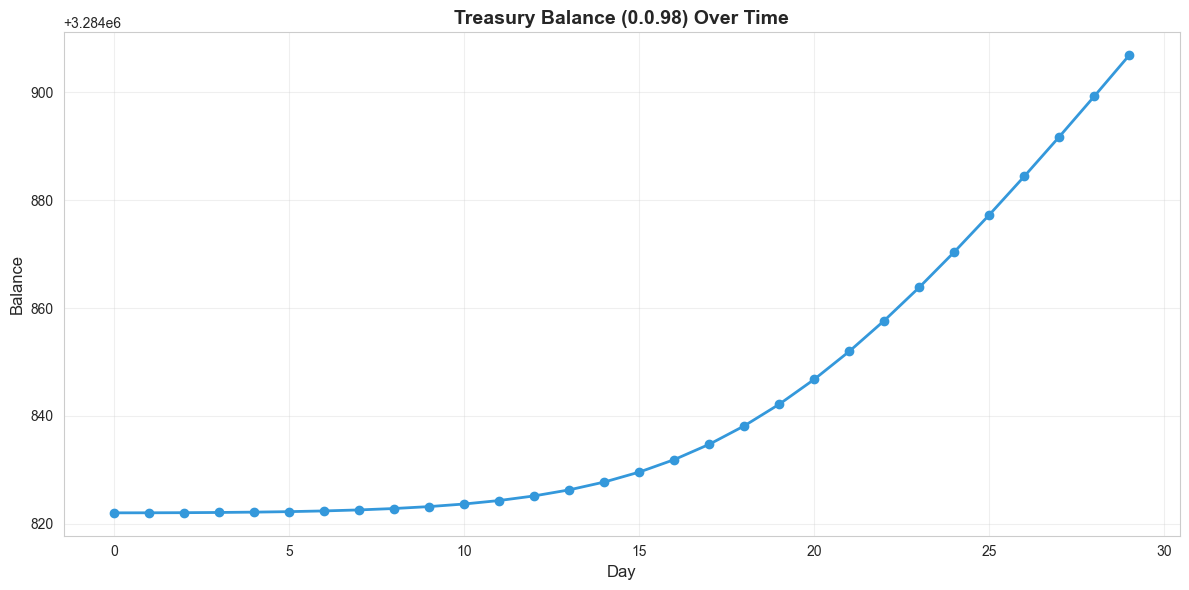

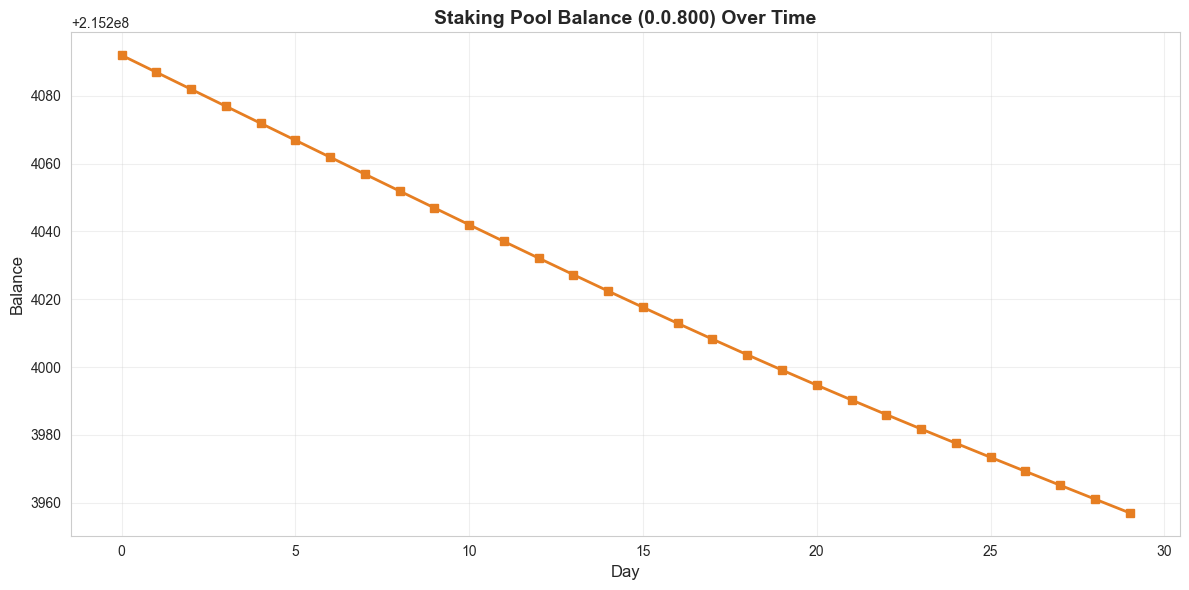

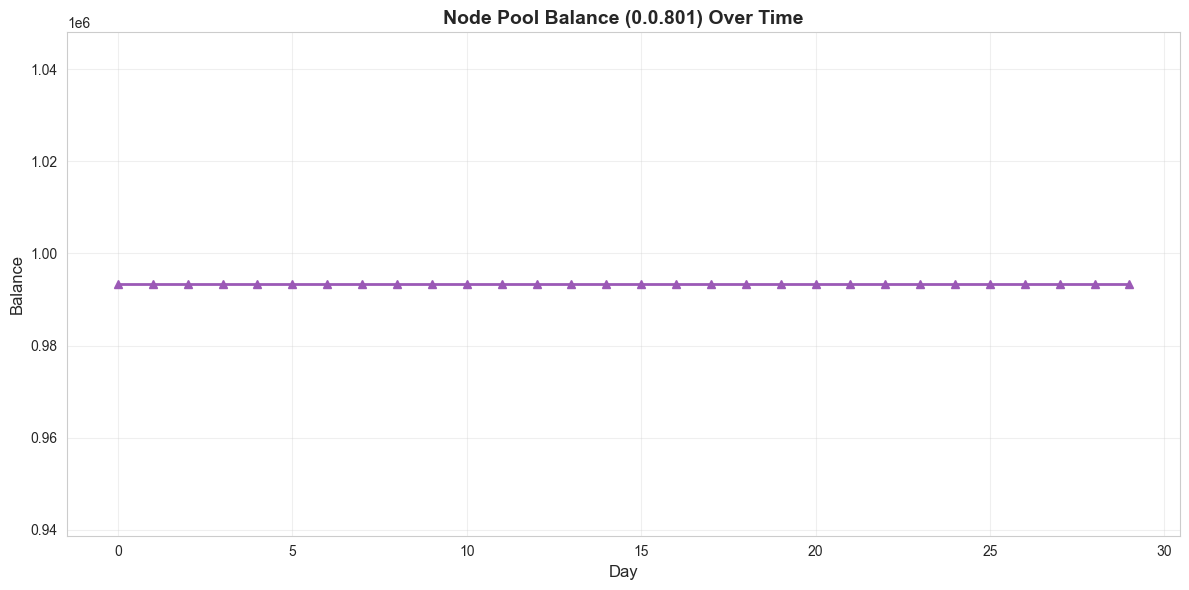

In [4]:
days = [s.day for s in history]

# Treasury Balance
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(days, [s.treasury_balance for s in history], linewidth=2, marker='o', color='#3498db')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Balance', fontsize=12)
ax.set_title('Treasury Balance (0.0.98) Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Staking Pool Balance
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(days, [s.staking_pool_balance for s in history], linewidth=2, marker='s', color='#e67e22')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Balance', fontsize=12)
ax.set_title('Staking Pool Balance (0.0.800) Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Node Pool Balance
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(days, [s.node_pool_balance for s in history], linewidth=2, marker='^', color='#9b59b6')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Balance', fontsize=12)
ax.set_title('Node Pool Balance (0.0.801) Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Total Staker and Node Balances Over Time

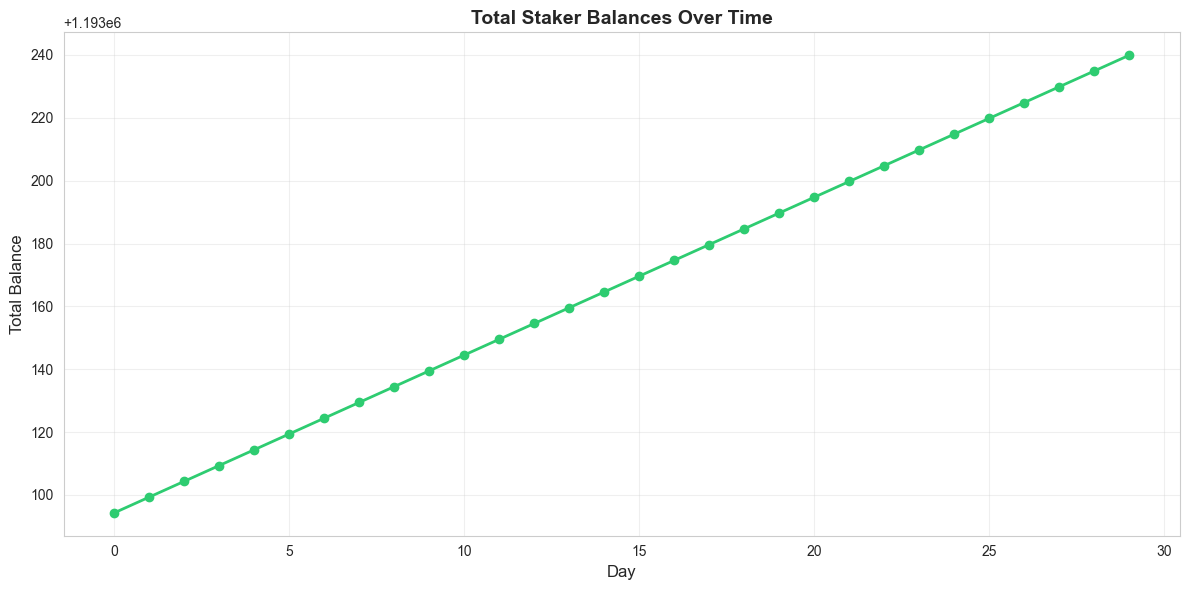

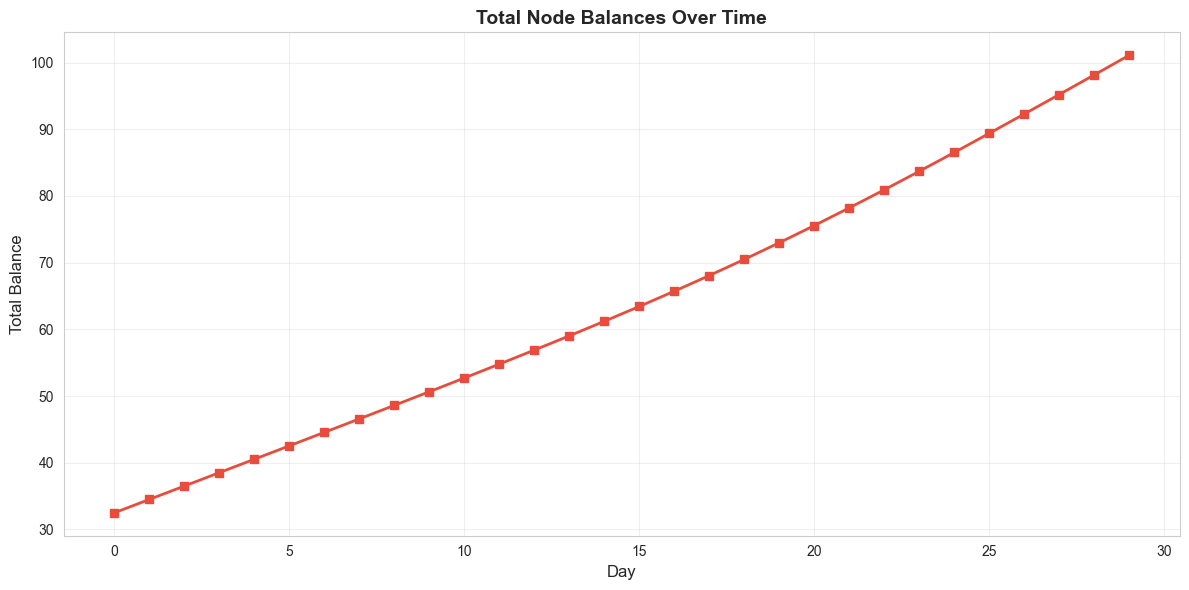

In [5]:
days = [s.day for s in history]

# Total Staker Balances
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(days, [s.total_staker_balance for s in history], linewidth=2, marker='o', color='#2ecc71')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Total Balance', fontsize=12)
ax.set_title('Total Staker Balances Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Total Node Balances
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(days, [s.total_node_balance for s in history], linewidth=2, marker='s', color='#e74c3c')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Total Balance', fontsize=12)
ax.set_title('Total Node Balances Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Rewards Distribution Over Time

This plot shows the **daily rewards actually credited** to stakers and nodes in the current `StakingEnvironment` model.

**How rewards work now:**
- `step_day()` snapshots the staking graph, computes rewardable stake per node, and routes network service fees through `FeeCollection`
- Staker rewards come from `StakingRewardsPool` and are distributed across stakers based on their effective stake after node caps are applied
- Node rewards include both per-node transaction fee payments and any additional rewards paid out from `NodeRewardsPool`
- `active_nodes` counts nodes with positive rewardable stake on that day


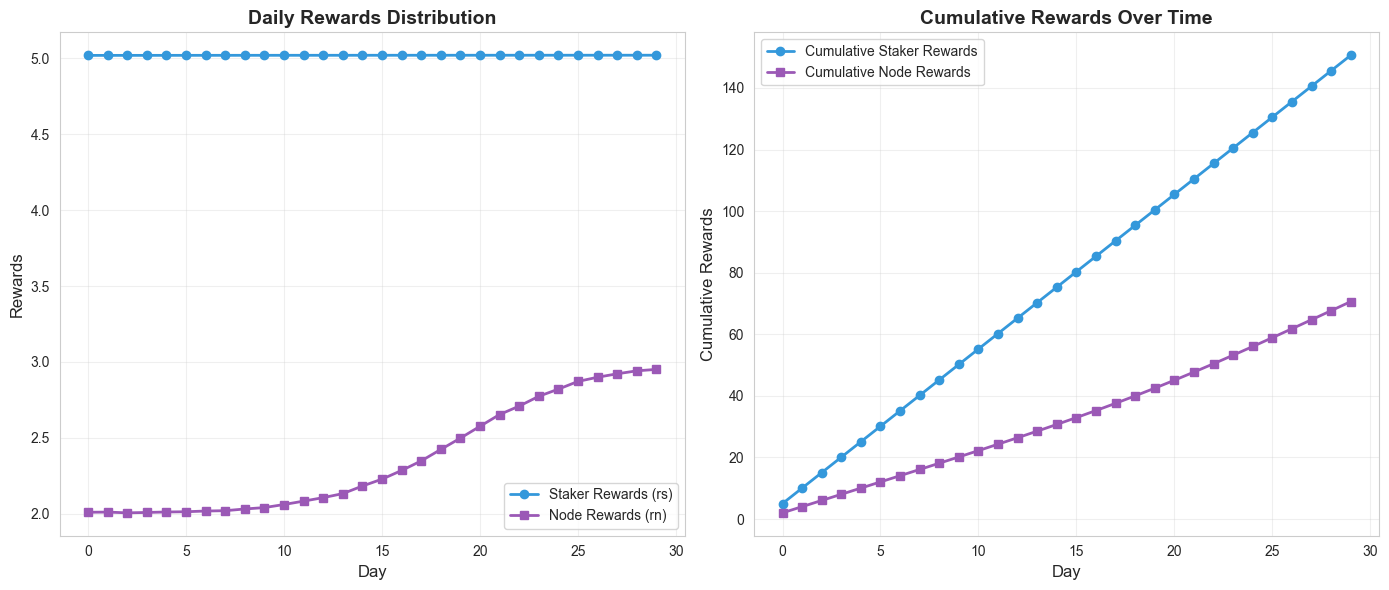

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

days = [s.day for s in history]
staker_rewards = [s.rs for s in history]
node_rewards = [s.rn for s in history]

# Daily rewards
ax1.plot(days, staker_rewards, label='Staker Rewards (rs)', linewidth=2, marker='o', color='#3498db')
ax1.plot(days, node_rewards, label='Node Rewards (rn)', linewidth=2, marker='s', color='#9b59b6')
ax1.set_xlabel('Day', fontsize=12)
ax1.set_ylabel('Rewards', fontsize=12)
ax1.set_title('Daily Rewards Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Cumulative rewards
cumulative_staker = np.cumsum(staker_rewards)
cumulative_node = np.cumsum(node_rewards)
ax2.plot(days, cumulative_staker, label='Cumulative Staker Rewards', linewidth=2, marker='o', color='#3498db')
ax2.plot(days, cumulative_node, label='Cumulative Node Rewards', linewidth=2, marker='s', color='#9b59b6')
ax2.set_xlabel('Day', fontsize=12)
ax2.set_ylabel('Cumulative Rewards', fontsize=12)
ax2.set_title('Cumulative Rewards Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Fees and Net Flow

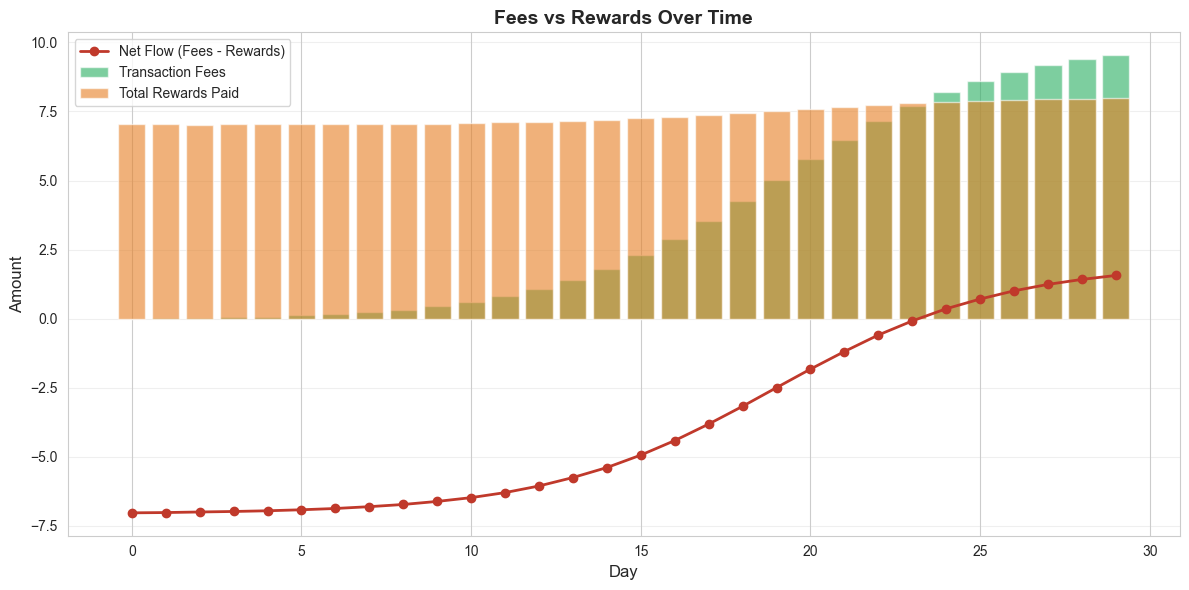

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

days = [s.day for s in history]
fees = [s.fees for s in history]
total_rewards = [s.rs + s.rn for s in history]
net_flow = [f - r for f, r in zip(fees, total_rewards)]

ax.bar(days, fees, alpha=0.6, label='Transaction Fees', color='#27ae60')
ax.bar(days, total_rewards, alpha=0.6, label='Total Rewards Paid', color='#e67e22')
ax.plot(days, net_flow, label='Net Flow (Fees - Rewards)', linewidth=2, marker='o', color='#c0392b')

ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Amount', fontsize=12)
ax.set_title('Fees vs Rewards Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 5. Top Stakers and Nodes (Final Rankings)

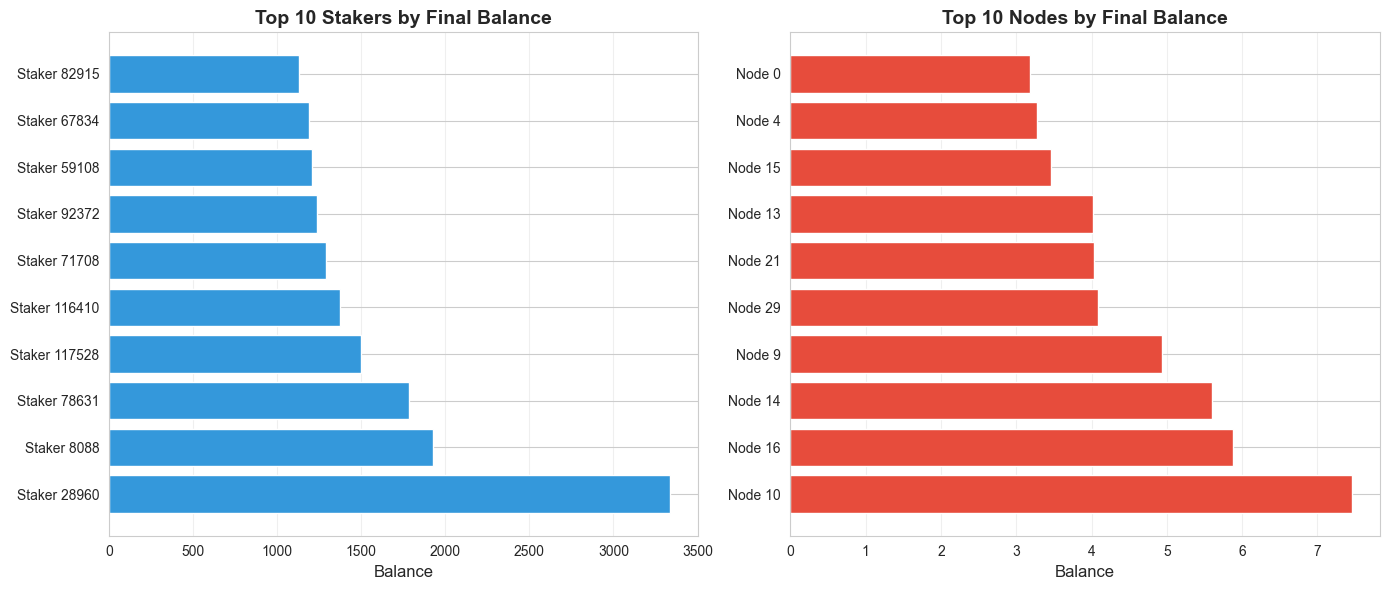

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

staker_balances = env.balance_stakers_account
node_balances = env.balance_nodes_account

# Top 10 stakers
top_stakers = sorted(staker_balances.items(), key=lambda kv: kv[1], reverse=True)[:10]
staker_ids = [f"Staker {sid}" for sid, _ in top_stakers]
staker_vals = [bal for _, bal in top_stakers]

ax1.barh(range(len(staker_ids)), staker_vals, color='#3498db')
ax1.set_yticks(range(len(staker_ids)))
ax1.set_yticklabels(staker_ids)
ax1.set_xlabel('Balance', fontsize=12)
ax1.set_title('Top 10 Stakers by Final Balance', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Top 10 nodes
top_nodes = sorted(node_balances.items(), key=lambda kv: kv[1], reverse=True)[:10]
node_ids = [f"Node {nid}" for nid, _ in top_nodes]
node_vals = [bal for _, bal in top_nodes]

ax2.barh(range(len(node_ids)), node_vals, color='#e74c3c')
ax2.set_yticks(range(len(node_ids)))
ax2.set_yticklabels(node_ids)
ax2.set_xlabel('Balance', fontsize=12)
ax2.set_title('Top 10 Nodes by Final Balance', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## 6. Rewards Distribution Histogram

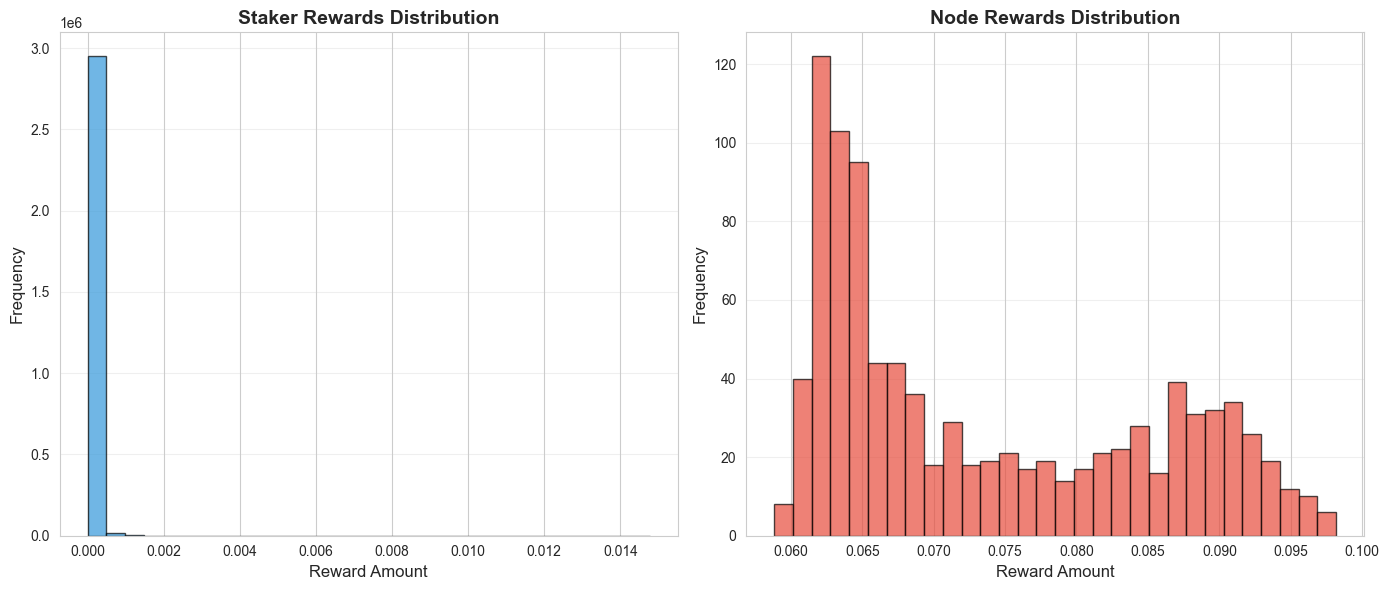

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Collect all rewards across all days
all_staker_rewards = []
all_node_rewards = []
for snapshot in history:
    all_staker_rewards.extend([r for r in snapshot.staker_rewards.values() if r > 0])
    all_node_rewards.extend([r for r in snapshot.node_rewards.values() if r > 0])

# Staker rewards distribution
if all_staker_rewards:
    ax1.hist(all_staker_rewards, bins=30, color='#3498db', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Reward Amount', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Staker Rewards Distribution', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

# Node rewards distribution
if all_node_rewards:
    ax2.hist(all_node_rewards, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Reward Amount', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Node Rewards Distribution', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Balance Distribution (Final State)

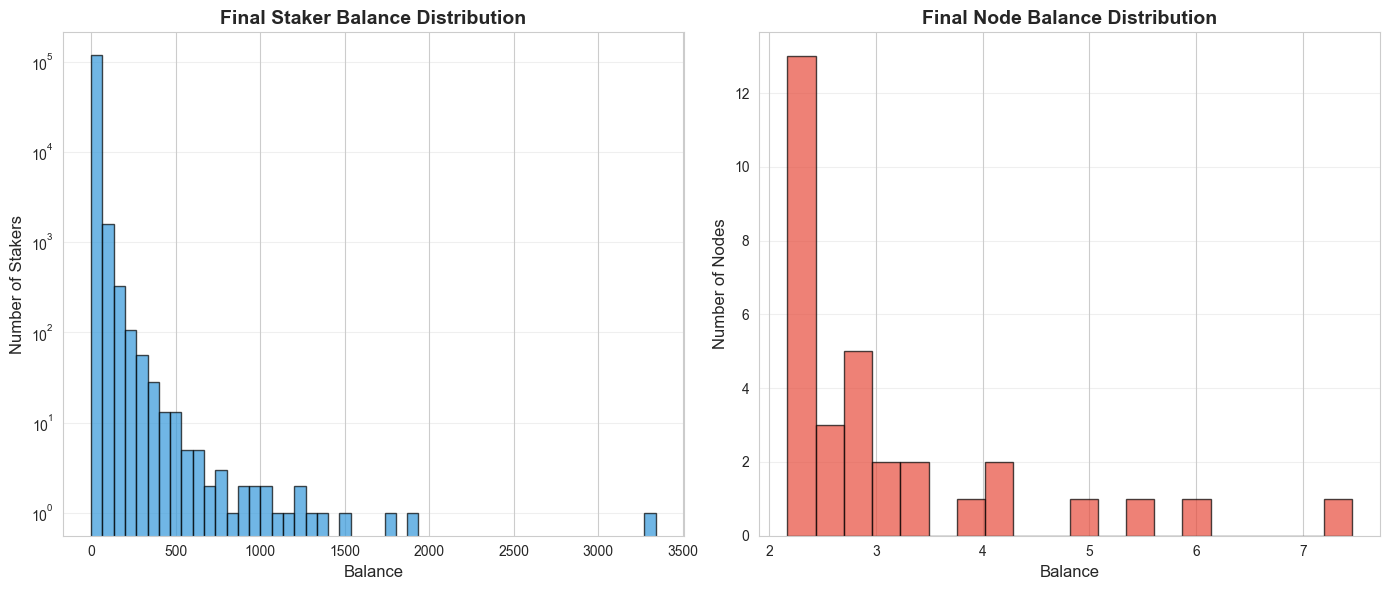

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

staker_balances = list(env.balance_stakers_account.values())
node_balances = list(env.balance_nodes_account.values())

# Staker balance distribution
ax1.hist(staker_balances, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Balance', fontsize=12)
ax1.set_ylabel('Number of Stakers', fontsize=12)
ax1.set_title('Final Staker Balance Distribution', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_yscale('log')

# Node balance distribution
ax2.hist(node_balances, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Balance', fontsize=12)
ax2.set_ylabel('Number of Nodes', fontsize=12)
ax2.set_title('Final Node Balance Distribution', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 8. Summary Statistics Table

In [12]:
# Create summary DataFrame
summary_data = {
    'Day': [s.day for s in history],
    'Fees': [s.fees for s in history],
    'Staker Rewards': [s.rs for s in history],
    'Node Rewards': [s.rn for s in history],
    'Treasury Balance': [s.treasury_balance for s in history],
    'Staking Pool Balance': [s.staking_pool_balance for s in history],
    'Node Pool Balance': [s.node_pool_balance for s in history],
    'Total Staker Balance': [s.total_staker_balance for s in history],
    'Total Node Balance': [s.total_node_balance for s in history],
    'Active Nodes': [s.active_nodes for s in history],
}

df = pd.DataFrame(summary_data)

# Display summary statistics
print("=== Summary Statistics ===")
print(df.describe())
print("\n=== Final State ===")
print(df.iloc[-1])

# Display first few rows
print("\n=== First 5 Days ===")
print(df.head())


=== Summary Statistics ===
             Day       Fees  Staker Rewards  Node Rewards  Treasury Balance  \
count  30.000000  30.000000       30.000000     30.000000      3.000000e+01   
mean   14.500000   3.537373        5.020694      2.353902      3.284843e+06   
std     8.803408   3.582312        0.000349      0.358830      2.641357e+01   
min     0.000000   0.000000        5.020000      2.005176      3.284822e+06   
25%     7.250000   0.257025        5.020447      2.022177      3.284823e+06   
50%    14.500000   2.060780        5.020756      2.204533      3.284829e+06   
75%    21.750000   6.974001        5.020984      2.694740      3.284856e+06   
max    29.000000   9.535461        5.021168      2.950616      3.284907e+06   

       Staking Pool Balance  Node Pool Balance  Total Staker Balance  \
count          3.000000e+01               30.0          3.000000e+01   
mean           2.152040e+08           993358.0          1.193167e+06   
std            4.128960e+01                0.

## 9. Cumulative Rewards Comparison

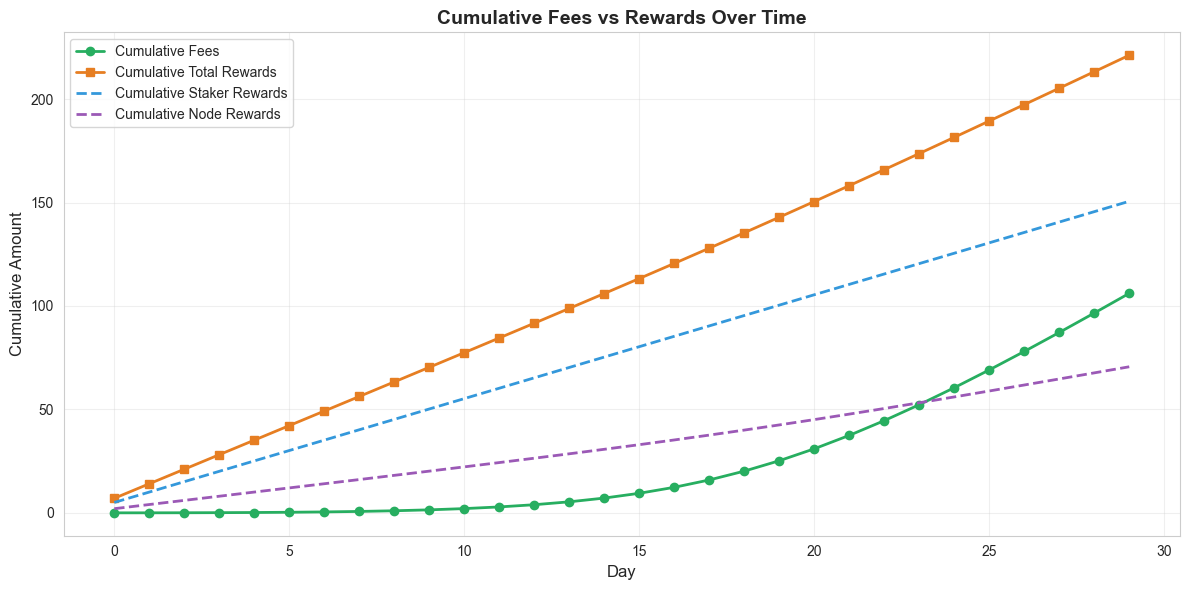

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

days = [s.day for s in history]
cumulative_fees = np.cumsum([s.fees for s in history])
cumulative_staker_rewards = np.cumsum([s.rs for s in history])
cumulative_node_rewards = np.cumsum([s.rn for s in history])
cumulative_total_rewards = cumulative_staker_rewards + cumulative_node_rewards

ax.plot(days, cumulative_fees, label='Cumulative Fees', linewidth=2, marker='o', color='#27ae60')
ax.plot(days, cumulative_total_rewards, label='Cumulative Total Rewards', linewidth=2, marker='s', color='#e67e22')
ax.plot(days, cumulative_staker_rewards, label='Cumulative Staker Rewards', linewidth=2, linestyle='--', color='#3498db')
ax.plot(days, cumulative_node_rewards, label='Cumulative Node Rewards', linewidth=2, linestyle='--', color='#9b59b6')

ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Cumulative Amount', fontsize=12)
ax.set_title('Cumulative Fees vs Rewards Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()